To construct our global partition of ENSO teleconnections, we examine whether reanalysis grid cells
exhibit surface temperatures that are positively correlated with NINO3 on a monthly basis (with a two month lag) for at least three months out of the year


In [1]:
#Nino_my = El Nino Index in month m, year y
# T(x, m, y) = surface temperature at location x, month m and year y
#  ρ(x, m, L) be the correlation coefficient (over all years y ∈ Y ) of NINO(m, y) and T(x, m + L, y)

In [2]:
import os
from dotenv import load_dotenv
import xarray as xr

from scipy import stats

import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import analysis_utils
import plotting_utils
import isku_utils

import importlib

importlib.reload(analysis_utils)
importlib.reload(isku_utils)

import diagnostic_utils

importlib.reload(diagnostic_utils)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'diagnostic_utils' from '/home/emily_zuetell/projects/poreallas/analysis/diagnostic_utils.py'>

In [3]:
# Projection Effects
load_dotenv()
# Baseline period for Impact
EFFECTS_URI = os.environ["POREALLAS_EFFECTS_URI"]
effect = xr.open_datatree(EFFECTS_URI, consolidated=False)
BASELINE_PERIOD = analysis_utils.get_baseline_period(effect, years=30)
# Define Forecast Months
FC_MONTHS = [9, 10, 11, 12, 1, 2]
FC_PERIOD = slice("2026-09-01", "2027-02-28")

config = analysis_utils.ImpactConfig( version = "v260929",
                                     baseline_period=BASELINE_PERIOD, 
                                     polygons_path= os.environ["POREALLAS_REGIONS_POLYGONS_URI"],
                                     socioeconomics_path= os.environ["POREALLAS_SOCIOECONOMICS_URI"],
                                     rate=True, 
                                     months = FC_MONTHS,
                                     hotonly = "net", 
                                     age_weight= False,
                                     dims = ['number', 'sample'])

In [4]:
def nino34_index(ds, var="tas", clim=("1991-01-01", "2020-12-31"), oni=True):
    ## Based on: https://climatedataguide.ucar.edu/climate-data/nino-sst-indices-nino-12-3-34-4-oni-and-tni
    # Compute NINO3.4 Index from ERA5 reanalysis
    sst = ds[var]
    # Make sure lat is ascending
    sst = sst.sortby("lat")
    # Set NINO3.4 Bounding Box
    box = sst.sel(lat=slice(-5, 5), lon=slice(-170, -120))
    # Daily -> Monthly TAS
    monthly = box.resample(time="1MS").mean()
    # Compute area averaged total SST from Niño X region
    weights = np.cos(np.deg2rad(monthly.lat))
    area_mean = monthly.weighted(weights).mean(("lat", "lon"))

    # subtract climatology from area averaged total SST time series to obtain anomalies
    climatology = area_mean.sel(time=slice(*clim)).groupby("time.month").mean()
    anom = area_mean.groupby("time.month") - climatology

    if oni:
        #Smooth the anomalies with a 3-month running mean
            anom = anom.rolling(time=3, center=True).mean()
    # Normalize
    std = anom.sel(time=slice(*clim)).std("time")
    return (anom / std).drop_vars("month")

In [5]:
def lagged_corr_by_month(da, nino, lags):
    # Compute Monthly lagged correlation
    def corr_one_lag(lag):
        # Align xarrays
        pair = xr.Dataset({"x": da, "y": nino.shift(time=lag)})
        # Compute Corr
        return pair.groupby("time.month").map(
            lambda g: xr.corr(g.x, g.y, dim="time")
        )

    return xr.concat(
        [corr_one_lag(lag) for lag in lags],
        dim=xr.DataArray(list(lags), dims="lag", name="lag"),
    )

In [6]:
## Build NINO3.4 Index from ERA5 (Note Sol uses NINO3, but https://climatedataguide.ucar.edu/climate-data/nino-sst-indices-nino-12-3-34-4-oni-and-tni says 3.4 is better )
uri_raw = "/home/emily_zuetell/projects/poreallas/data/v20260903_parsed_era5.zarr"
uri_adj = "/home/emily_zuetell/projects/poreallas/data/era5_adj_corrected.zarr"
_ds = xr.open_dataset(
    uri_raw,
    engine="zarr",
    chunks={},
)
# Adjust (only if using adj dataset)
#_ds = isku_utils.lon_adjust(_ds, roll=True)
# Monthly TAS
monthly = _ds.resample(time="1MS").mean()

# TAS by Impact Region
era5_ir = isku_utils.grid_to_ir(monthly, savefile=None)

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:29: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


In [7]:
nino34 = nino34_index(_ds)

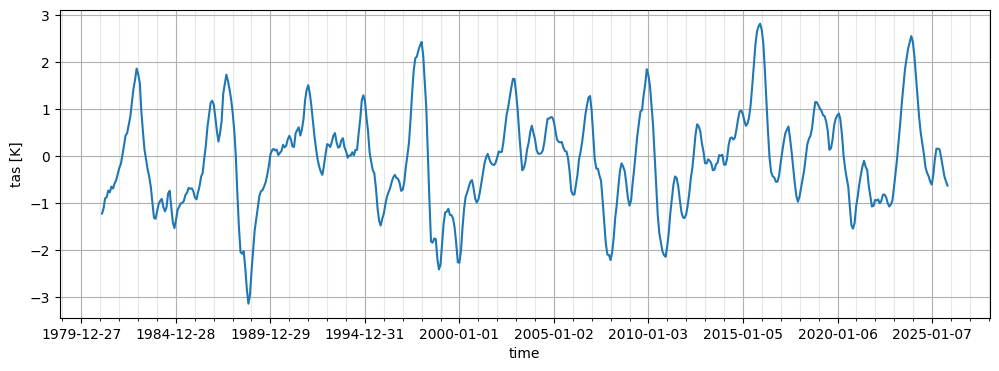

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
nino34.plot(ax=ax)

ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_minor_locator(mdates.YearLocator(1))
ax.grid(True, which="major")
ax.grid(True, which="minor", alpha=0.3)

In [9]:
def corr_pvalue(r, n):
    # Student's t-distribution with n − 2 degrees of freedom
    t = r * np.sqrt((n - 2) / (1 - r**2))
    # Two-sided survival function
    return xr.apply_ufunc(
        lambda t, df: 2 * stats.t.sf(np.abs(t), df),
        t, n - 2,
        dask="parallelized",
        output_dtypes=[float],
    )

In [10]:
# Lag = 2 (Based on Hsiang et al. 2011)
lags = [2]
# Compute correlation
r = lagged_corr_by_month(era5_ir['tas'], nino34, lags)
# n = valid year pairs (for statistical significance)
n = xr.concat(
    [
        (era5_ir['tas'].notnull() & nino34.shift(time=lag).notnull()).groupby("time.month").sum("time")
        for lag in lags
    ],
    dim=xr.DataArray(list(lags), dims="lag", name="lag"),
)
# p-value
p = corr_pvalue(r, n)
# Binary signficance threshold (alpha = 0.1)
rho_tilde = ((p <= 0.1) & (r > 0)).astype(int)

In [11]:
_polygons_teleconnection = analysis_utils.xarray_to_gpd(
    (rho_tilde.sum(dim="month")), config.polygons
)

<Axes: >

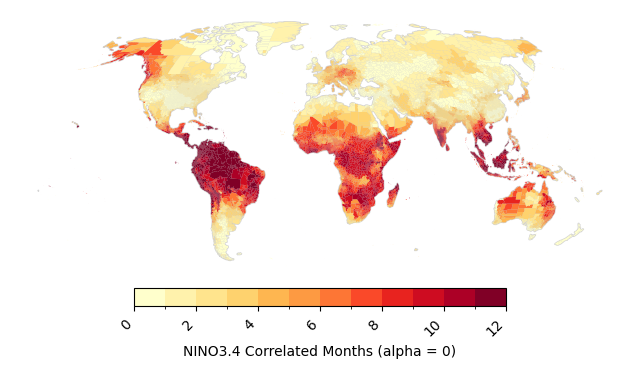

In [12]:
plotting_utils.plot_single(
    _polygons_teleconnection,
    col="value",
    cm="YlOrRd",
    n_colors=13,
    vmin=0,
    vmax=12,
    sup_title="",
    cbar_label="NINO3.4 Correlated Months (alpha = 0)",
    cbar_location="bottom",
)

In [13]:
_polygons_teleconnection_binary = analysis_utils.xarray_to_gpd(
    (rho_tilde.sum(dim="month") >= 5), config.polygons
)

<Axes: >

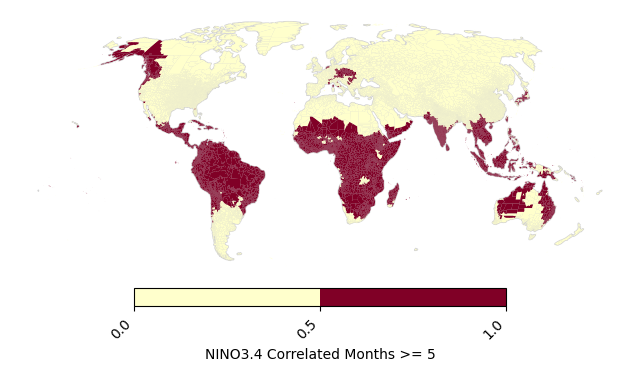

In [14]:
plotting_utils.plot_single(
    _polygons_teleconnection_binary,
    col="value",
    cm="YlOrRd",
    n_colors=2,
    vmin=0,
    vmax=1,
    sup_title="",
    cbar_label=f"NINO3.4 Correlated Months >= 5",
    cbar_location="bottom",
)

In [15]:
# Scatter Plot
load_dotenv()
EFFECTS_URI = os.environ["POREALLAS_EFFECTS_URI"]
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]

# Climate Data
TAS_FORECAST_URI = os.environ["POREALLAS_TAS_FORECAST_URI"]
ERA5_URI = os.environ["POREALLAS_ERA5_URI"]
TAS_FORECAST_RAW = os.environ["POREALLAS_PARSED_FORECAST_URI"]
# Projection Effects
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
# Baseline period for Impact
effect = xr.open_datatree(EFFECTS_URI, consolidated=False)
BASELINE_PERIOD = analysis_utils.get_baseline_period(effect, years=30)
# Define Forecast Months
FC_MONTHS = [9, 10, 11, 12, 1, 2]
FC_PERIOD = slice("2026-09-01", "2027-02-28")

config = analysis_utils.ImpactConfig( version = "v260910",
                                     baseline_period=BASELINE_PERIOD, 
                                     polygons_path= os.environ["POREALLAS_REGIONS_POLYGONS_URI"],
                                     socioeconomics_path= os.environ["POREALLAS_SOCIOECONOMICS_URI"],
                                     rate=True, 
                                     months = FC_MONTHS,
                                     hotonly = "hotonly", 
                                     dims = ['number', 'sample'])

In [18]:
s51

<xarray.Dataset> Size: 3GB
Dimensions:                  (number: 51, lat: 180, lon: 360, time: 215)
Coordinates:
  * number                   (number) int64 408B 0 1 2 3 4 5 ... 46 47 48 49 50
  * lat                      (lat) float64 1kB 89.5 88.5 87.5 ... -88.5 -89.5
  * lon                      (lon) float64 3kB -179.5 -178.5 ... 178.5 179.5
  * time                     (time) object 2kB 2026-09-02 00:00:00 ... 2027-0...
    forecast_period          (time) timedelta64[ns] 2kB dask.array<chunksize=(215,), meta=np.ndarray>
    forecast_reference_time  (time) datetime64[ns] 2kB dask.array<chunksize=(215,), meta=np.ndarray>
Data variables:
    tas                      (number, lat, lon, time) float32 3GB dask.array<chunksize=(51, 30, 2, 215), meta=np.ndarray>
Attributes:
    poreallas_created_at:   2026-09-09T17:20:07.092312+00:00
    poreallas_uid:          2958930b-7f7e-46db-9a7e-6e8d8cf99826
    poreallas_description:  Parsed ECMWF S51 ensemble fields

In [19]:
### Seasonal Forecast ###
# Raw Forecast/Hindcast
forecast = xr.open_zarr(
    "/home/emily_zuetell/projects/poreallas/data/v20260909_forecast_parsed.zarr"
)
hindcast = xr.open_zarr("/home/emily_zuetell/projects/poreallas/data/v20260909_hindcast_climatology_1996_2025.zarr")

In [24]:
fc_anomaly = forecast["tas"] - hindcast["tas"]
fc_anomaly_ir = isku_utils.grid_to_ir(fc_anomaly.var(dim = 'number'))

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:29: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


In [25]:
fc_anomaly_ir

<xarray.DataArray (region: 24378, time: 215, month: 6)> Size: 126MB
dask.array<rechunk-merge, shape=(24378, 215, 6), dtype=float32, chunksize=(24378, 215, 6), chunktype=numpy.ndarray>
Coordinates:
  * region                   (region) object 195kB 'ABW' ... 'ZWE.9.R19a261b6...
  * time                     (time) object 2kB 2026-09-02 00:00:00 ... 2027-0...
    forecast_period          (time) timedelta64[ns] 2kB dask.array<chunksize=(215,), meta=np.ndarray>
    forecast_reference_time  (time) datetime64[ns] 2kB dask.array<chunksize=(215,), meta=np.ndarray>
  * month                    (month) int64 48B 9 10 11 12 1 2
Attributes: (12/31)
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      64800
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            regular_ll
    ...                                       ...
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0
    poreallas_created_at:                     2026-09-09T17:20:07.092312+00:00
    poreallas_uid:                            2958930b-7f7e-46db-9a7e-6e8d8cf...
    poreallas_description:                    Parsed ECMWF S51 ensemble tas f...

In [23]:
rho_tilde

<xarray.DataArray (lag: 1, month: 12, region: 24378)> Size: 2MB
dask.array<astype, shape=(1, 12, 24378), dtype=int64, chunksize=(1, 1, 24378), chunktype=numpy.ndarray>
Coordinates:
  * lag      (lag) int64 8B 2
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * region   (region) object 195kB 'ABW' ... 'ZWE.9.R19a261b63a503c9c'
Attributes:
    units:                  K
    poreallas_created_at:   2026-09-03T21:42:46.867340+00:00
    poreallas_uid:          6f37a45a-d7c2-4449-9f6d-faab21269ea3
    poreallas_description:  Parsed ERA5 tas field

/tmp/ipykernel_25509/1205402991.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'month' ('month',) The recommendation is to set join explicitly for this case.
  ds = xr.merge([rho_tilde.rename("teleconnection"), fc_anomaly_ir.rename("anomaly_var")])


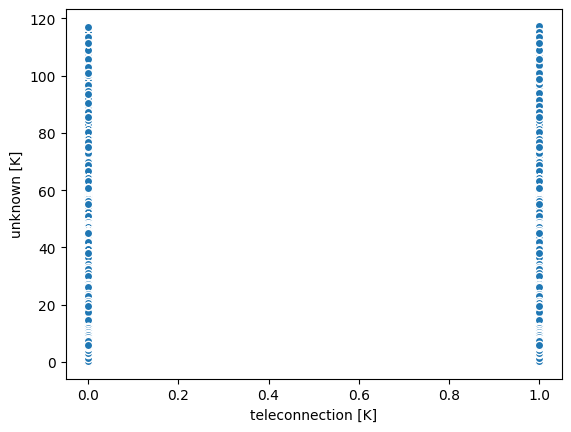

In [26]:
ds = xr.merge([rho_tilde.rename("teleconnection"), fc_anomaly_ir.rename("anomaly_var")])
ds.plot.scatter(x="teleconnection", y="anomaly_var")